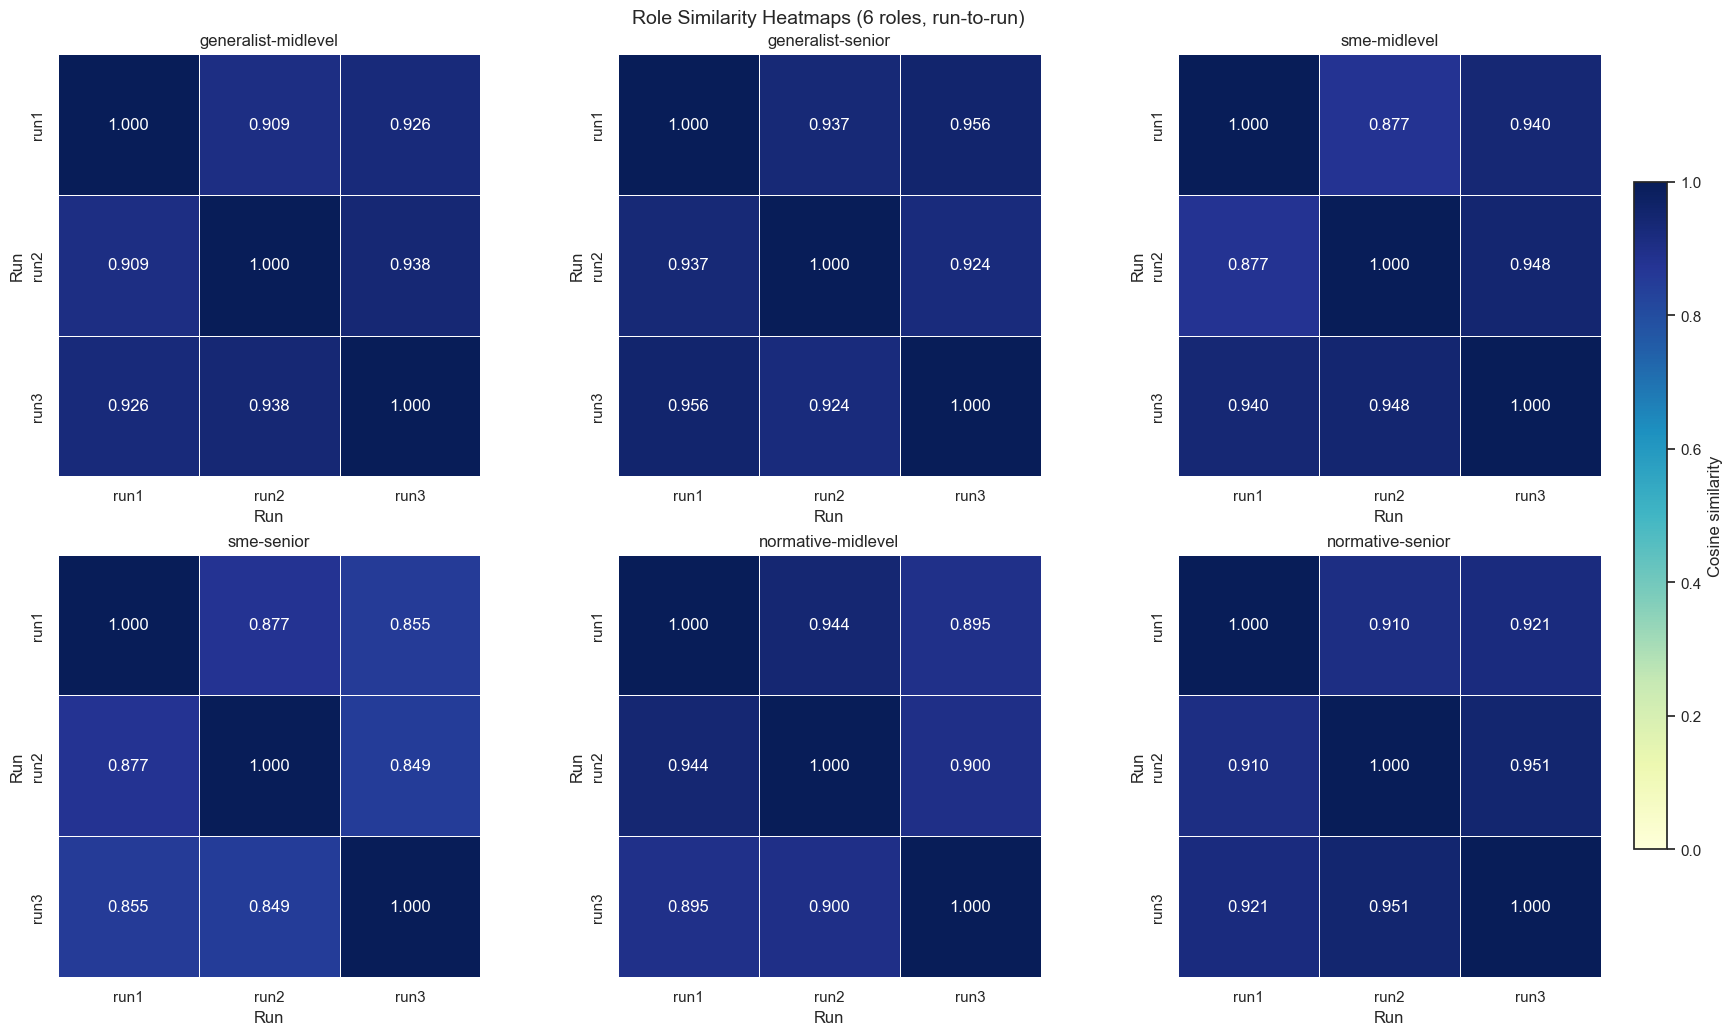

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# path from your pipeline output
csv_path = "/Users/HP/Documents/scrapping/working_dir/final_mds/llm-generated-roles/role-similarity.csv"
df = pd.read_csv(csv_path)

# expected 6 role keys
role_order = [
    "generalist-midlevel",
    "generalist-senior",
    "sme-midlevel",
    "sme-senior",
    "normative-midlevel",
    "normative-senior",
]

# all runs present
runs = sorted(set(df["run_a"]).union(set(df["run_b"])))
if "" in runs:
    runs.remove("")  # exclude untagged rows if any

sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for ax, role_key in zip(axes.flat, role_order):
    sub = df[df["role_key"] == role_key].copy()

    # start empty matrix
    mat = pd.DataFrame(np.nan, index=runs, columns=runs, dtype=float)
    np.fill_diagonal(mat.values, 1.0)

    # fill pairwise scores (symmetric)
    for _, r in sub.iterrows():
        ra, rb, s = r["run_a"], r["run_b"], float(r["cosine_similarity"])
        if ra in mat.index and rb in mat.columns:
            mat.loc[ra, rb] = s
            mat.loc[rb, ra] = s

    sns.heatmap(
        mat,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(role_key)
    ax.set_xlabel("Run")
    ax.set_ylabel("Run")

# single shared colorbar
sm = plt.cm.ScalarMappable(cmap="YlGnBu", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, label="Cosine similarity")

plt.suptitle("Role Similarity Heatmaps (6 roles, run-to-run)", y=1.02, fontsize=14)
plt.show()


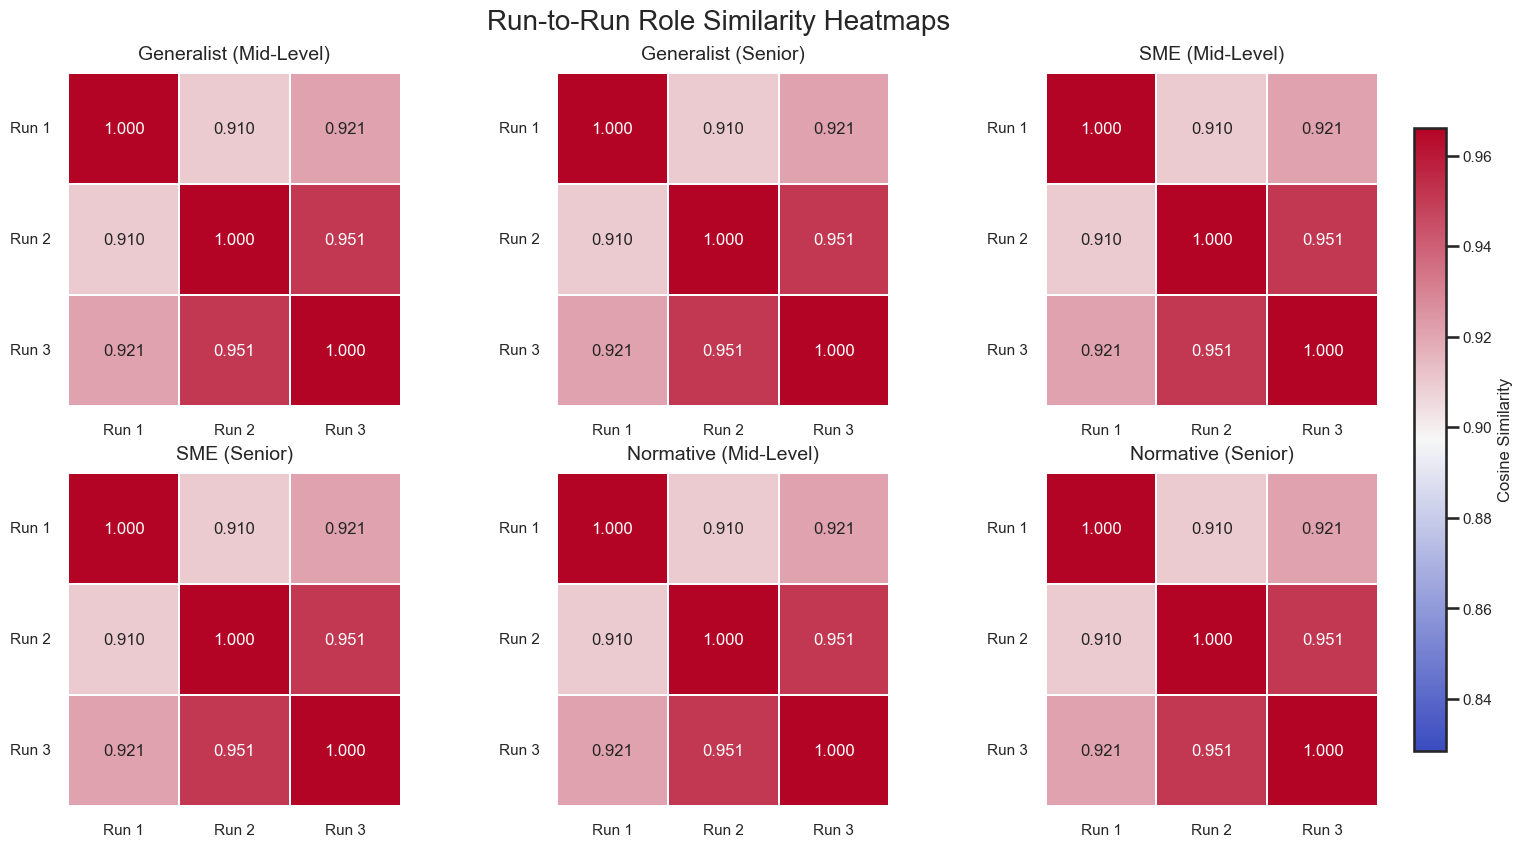

Saved PNG: /Users/HP/Documents/EPIA-publication/working_dir/final_mds/llm-generated-roles/role-heatmaps-2x3.png
Saved PDF: /Users/HP/Documents/EPIA-publication/working_dir/final_mds/llm-generated-roles/role-heatmaps-2x3.pdf
Saved EPS: /Users/HP/Documents/EPIA-publication/working_dir/final_mds/llm-generated-roles/role-heatmaps-2x3.eps


In [ ]:
# Heatmap grid (2x3) for role similarity across runs
# Works with: role-similarity.csv from your pipeline

import pathlib
import re
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

# ---------- CONFIG ----------
CSV_PATH = "/Users/HP/Documents/EPIA-publication/working_dir/final_mds/llm-generated-roles/role-similarity.csv"
OUTPUT_DIR = pathlib.Path("/Users/HP/Documents/EPIA-publication/working_dir/final_mds/llm-generated-roles/")

# Rename role panels (edit as you like)
ROLE_LABELS = {
    "generalist-midlevel": "Generalist (Mid-Level)",
    "generalist-senior": "Generalist (Senior)",
    "sme-midlevel": "SME (Mid-Level)",
    "sme-senior": "SME (Senior)",
    "normative-midlevel": "Normative (Mid-Level)",
    "normative-senior": "Normative (Senior)",
}
VALUE_FONT_SIZE = 12       # numbers inside heatmap cells
TICK_FONT_SIZE = 11        # Run 1, Run 2, Run 3
PANEL_TITLE_SIZE = 14      # individual heatmap titles
COLORBAR_TICK_SIZE = 11
COLORBAR_LABEL_SIZE = 12
MAIN_TITLE_SIZE = 20

# Rename run labels (optional)
RUN_LABELS = {"run1": "Run 1", "run2": "Run 2", "run3": "Run 3"}

# Optional fixed order of 6 panels
ROLE_ORDER = [
    "generalist-midlevel", "generalist-senior",
    "sme-midlevel", "sme-senior",
    "normative-midlevel", "normative-senior"
]
# ----------------------------

df = pd.read_csv(CSV_PATH)
df["cosine_similarity"] = pd.to_numeric(df["cosine_similarity"], errors="coerce")
df = df.dropna(subset=["cosine_similarity"])

# keep cross-run pairs only
df = df[(df["run_a"].astype(str) != "") & (df["run_b"].astype(str) != "")].copy()

def run_sort_key(x):
    m = re.search(r"(\d+)$", str(x))
    return int(m.group(1)) if m else 10_000

all_runs = sorted(set(df["run_a"]).union(df["run_b"]), key=run_sort_key)
plot_runs = [RUN_LABELS.get(r, r) for r in all_runs]

# pretty colormap (R-like diverging feel)
cmap = LinearSegmentedColormap.from_list(
    "sim_cmap", ["#3b4cc0", "#f7f7f7", "#b40426"], N=256
)

sns.set_theme(style="white", context="talk")
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# Use stable color range for comparability across panels
vmin = max(0.0, df["cosine_similarity"].min() - 0.02)
vmax = min(1.0, df["cosine_similarity"].max() + 0.01)
for i, role_key in enumerate(ROLE_ORDER):
    ax = axes.flat[i]

    # Build mat_plot here...

    sns.heatmap(
        mat_plot,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        annot_kws={
            "fontsize": VALUE_FONT_SIZE,
        },
        fmt=".3f",
        square=True,
        linewidths=1.2,
        linecolor="white",
        cbar=False,
)

    ax.set_title(ROLE_LABELS.get(role_key, role_key), fontsize=PANEL_TITLE_SIZE, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, labelsize=TICK_FONT_SIZE)
    ax.tick_params(axis="y", rotation=0, labelsize=TICK_FONT_SIZE)

# Add one shared colorbar
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=vmin, vmax=vmax),
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.025,
    shrink=0.85,
)
cbar.set_label("Cosine Similarity", fontsize=COLORBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)

fig.suptitle("Heatmap of run-to-run role similarity", fontsize=MAIN_TITLE_SIZE, y=1.04)
png_path = OUTPUT_DIR / "role-heatmaps-2x3.png"
pdf_path = OUTPUT_DIR / "role-heatmaps-2x3.pdf"
eps_path = OUTPUT_DIR / "role-heatmaps-2x3.eps"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig(eps_path, format="eps", bbox_inches="tight")

plt.show()

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")
print(f"Saved EPS: {eps_path}")
plt.show()



# Final decision based on the similarity scores and human evaluation: 
SME-midlevel: (run3)
SME-senior: (run2)
normative-midlevel: (run3)
normative-senior: (run2)
generalist-midlevel: (run2)
generalist-senior: (run3)